# Libraries

In [452]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [453]:
# Set visual style for professional presentation slides
sns.set_theme(style="whitegrid", palette="muted")

In [454]:
# 1. Load the cleaned master dataset
df = pd.read_csv('../data/processed/olist_master_dataset.csv')

# Convert timestamps to datetime objects

In [455]:
time_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Calculate actual delivery time in days

In [456]:
df['actual_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Calculate delivery delay (if negative, it arrived early)

In [457]:
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

In [458]:
df["delivery_delay_days"].value_counts().sort_index()

delivery_delay_days
-135.0    1
-84.0     1
-83.0     1
-78.0     1
-75.0     2
         ..
 162.0    1
 165.0    1
 166.0    1
 167.0    1
 175.0    1
Name: count, Length: 164, dtype: int64

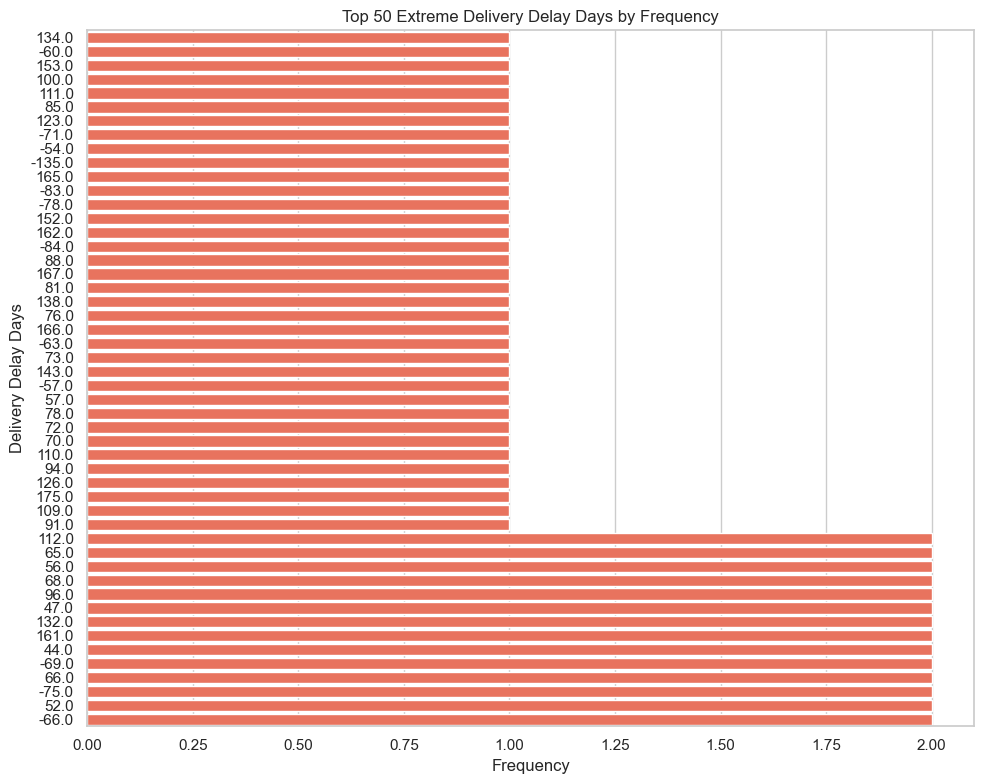

In [459]:
# Identify extreme values in delivery_delay_days using IQR
Q1 = df['delivery_delay_days'].quantile(0.25)
Q3 = df['delivery_delay_days'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

extreme_mask = (df['delivery_delay_days'] < lower_bound) | (df['delivery_delay_days'] > upper_bound)
extreme_delays = df.loc[extreme_mask, 'delivery_delay_days'].dropna()

# Plot the most frequent extreme delivery delays
extreme_counts = extreme_delays.value_counts().sort_values(ascending=True).head(50)

plt.figure(figsize=(10, 8))
sns.barplot(x=extreme_counts.values, y=extreme_counts.index.astype(str), color='tomato')
plt.title('Top 50 Extreme Delivery Delay Days by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Delivery Delay Days')
plt.tight_layout()
plt.show()


# Capping Actual_delivery_days and delivery_delay_days TO get rid off Extreme values

In [460]:
# Drop outliers in delivery_delay_days using the already computed IQR bounds
rows_before = len(df)

df = df[(df['delivery_delay_days'].isna()) | 
    (df['delivery_delay_days'].between(lower_bound, upper_bound))].copy()

rows_after = len(df)
print(f"Rows before: {rows_before}")
print(f"Rows after : {rows_after}")
print(f"Outlier rows removed: {rows_before - rows_after}")

Rows before: 48166
Rows after : 45350
Outlier rows removed: 2816


In [461]:
df[['price', 'freight_value', 'product_weight_g', 'product_length_cm', 
    'product_height_cm', 'product_width_cm', 'review_score', 
    'actual_delivery_days', 'delivery_delay_days']].dropna().describe().T

,count,mean,std,min,25%,50%,75%,max
price,43307.0,105.562222,93.353946,0.85,39.99,75.00,134.99,369.000
freight_value,43307.0,19.404410,10.899239,0.33,13.08,16.35,21.47,47.829
product_weight_g,43307.0,2206.065463,3907.190852,0.00,300.00,727.00,1850.00,30000.000
product_length_cm,43307.0,30.274182,16.041681,7.00,18.00,25.00,38.00,105.000
product_height_cm,43307.0,16.863255,13.776324,2.00,8.00,13.00,20.00,105.000
product_width_cm,43307.0,23.171727,11.739943,6.00,15.00,20.00,30.00,118.000
review_score,43307.0,3.723486,1.580122,1.00,3.00,5.00,5.00,5.000
actual_delivery_days,43307.0,11.540398,7.518238,0.00,6.00,10.00,15.00,71.000
delivery_delay_days,43307.0,-12.368532,7.613156,-32.00,-17.00,-13.00,-8.00,8.000


In [462]:
df.info()

<class 'pandas.DataFrame'>
Index: 45350 entries, 0 to 48165
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       45350 non-null  str           
 1   customer_id                    45350 non-null  str           
 2   order_status                   45350 non-null  str           
 3   order_purchase_timestamp       45350 non-null  datetime64[us]
 4   order_approved_at              45248 non-null  str           
 5   order_delivered_carrier_date   44038 non-null  str           
 6   order_delivered_customer_date  43321 non-null  datetime64[us]
 7   order_estimated_delivery_date  45350 non-null  datetime64[us]
 8   order_item_id                  44826 non-null  float64       
 9   product_id                     44826 non-null  str           
 10  seller_id                      44826 non-null  str           
 11  shipping_limit_date            

# The Distribution Of Price, Freight_Values, Delivery_Days, Delivery_Delays


Skewness:
price                   1.602568
freight_value           1.565594
actual_delivery_days    1.313025
delivery_delay_days     0.140779
dtype: float64


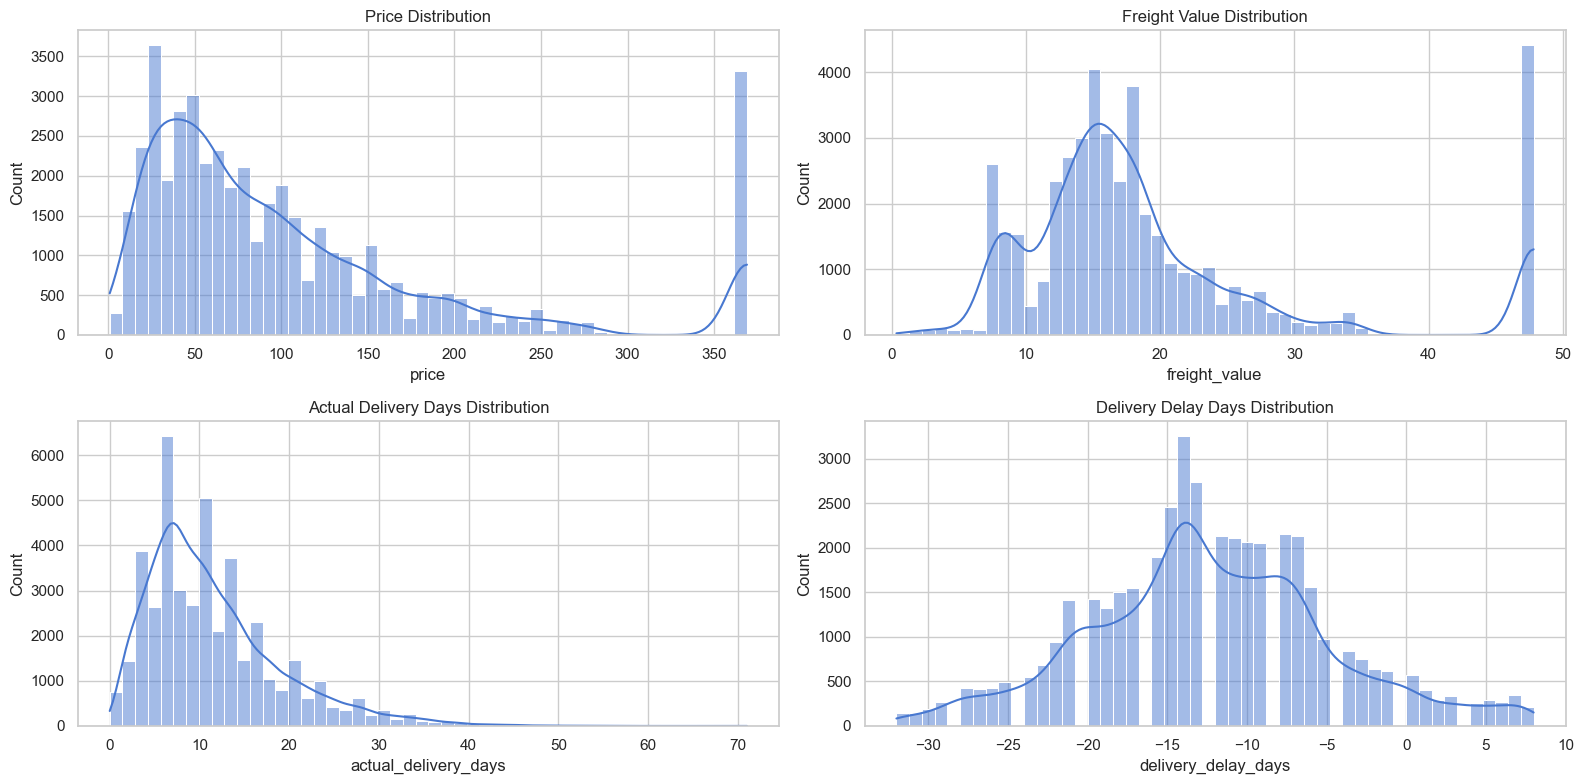

In [463]:
print("\nSkewness:")
print(df[['price', 'freight_value', 'actual_delivery_days','delivery_delay_days']].skew().T)
# Data Distribution Plots
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.subplot(2, 2, 2)
sns.histplot(df['freight_value'], bins=50, kde=True)
plt.title('Freight Value Distribution')
plt.subplot(2, 2, 3)
sns.histplot(df['actual_delivery_days'], bins=50, kde=True)
plt.title('Actual Delivery Days Distribution')
plt.subplot(2, 2, 4)
sns.histplot(df['delivery_delay_days'], bins=50, kde=True)
plt.title('Delivery Delay Days Distribution')
plt.tight_layout()
plt.show()

In [464]:
# for i in df.select_dtypes(include="number").columns:
#     sns.histplot(data=df, x=i)
#     plt.show()

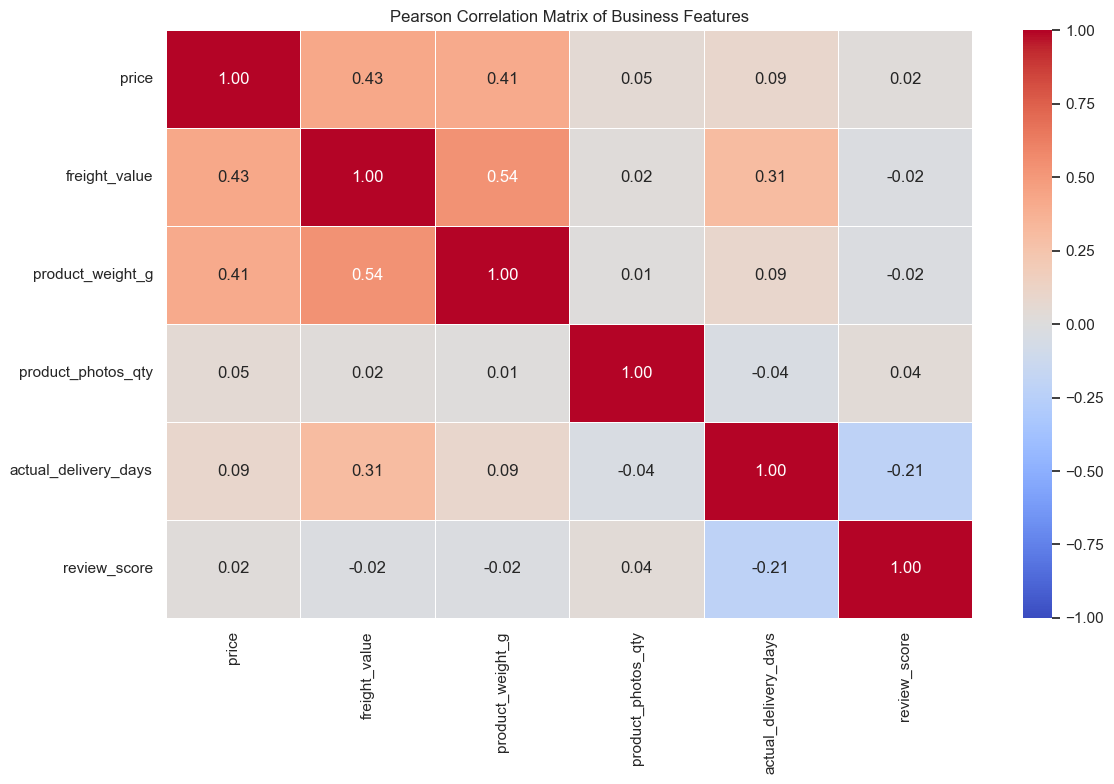

In [465]:
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
num_cols = ['price', 'freight_value', 'product_weight_g', 'product_photos_qty', 
            'actual_delivery_days', 'review_score']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix of Business Features")
plt.tight_layout()
plt.show()

# Calculate Recency, Frequency, and Monetary values

- Recency: Days since last purchase.

- Frequency: Total number of orders.

- Monetary: Total revenue generated.

In [466]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
})

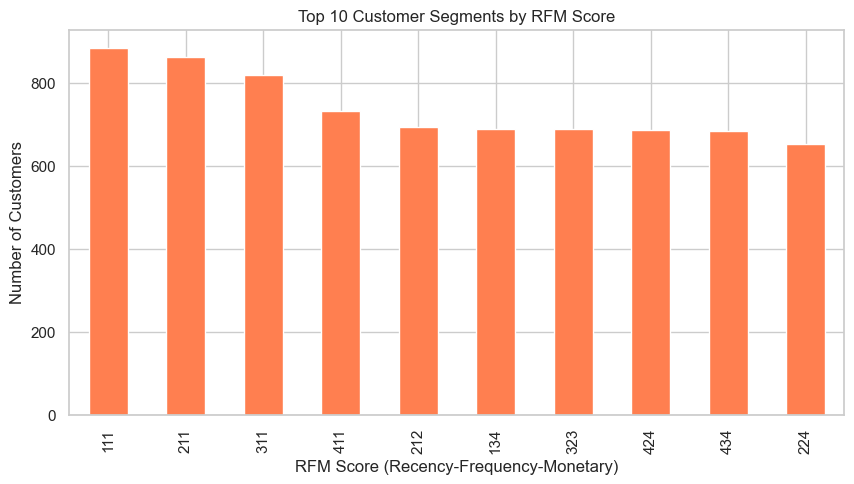

In [467]:
# 2. Create Quarters for scoring (1 is best, 4 is worst)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[1, 2, 3, 4])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[4, 3, 2, 1])

# 3. Combined RFM Score
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

plt.figure(figsize=(10, 5))
rfm['RFM_Group'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Customer Segments by RFM Score')
plt.xlabel('RFM Score (Recency-Frequency-Monetary)')
plt.ylabel('Number of Customers')
plt.show()

# We here calculate the rfm score for each customer and plot the distribution of the top 10 segments. This is a common technique in customer segmentation to identify high-value customers (e.g., those with RFM scores of 111) and those at risk of churn (e.g., those with RFM scores of 444).

# Visualization 1: The Impact of Delivery Time on Customer Satisfaction
- Business Insight: How heavily does logistics performance dictate the review score?

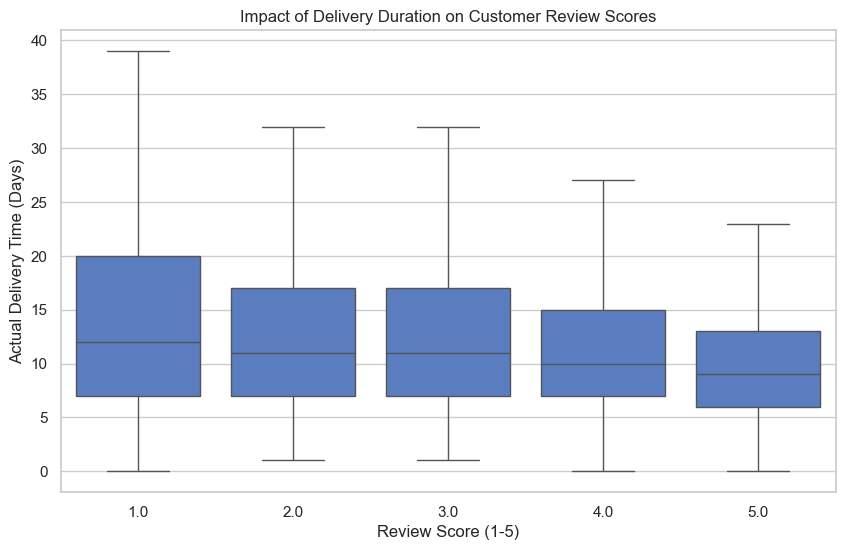

In [468]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='actual_delivery_days', data=df, showfliers=False)
plt.title('Impact of Delivery Duration on Customer Review Scores')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Actual Delivery Time (Days)')
plt.show()

# Visualization 2: Revenue by Product Category (Top 15)
- Business Insight: Which sectors are driving the actual gross profit for Olist?

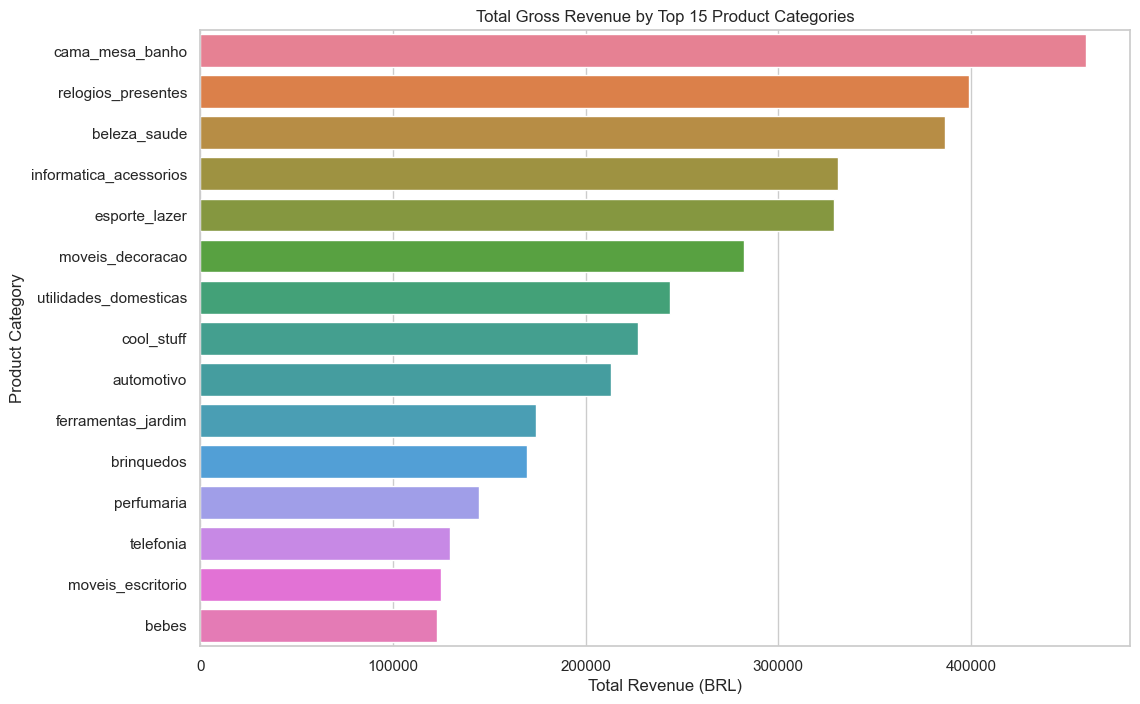

In [469]:
plt.figure(figsize=(12, 8))
# Group by category and sum the price
top_categories = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(15)

sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index)
plt.title('Total Gross Revenue by Top 15 Product Categories')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Product Category')
plt.show()

# Visualization 3: Freight Value vs. Product Weight
- Business Insight: Is shipping cost purely dictated by weight, or are there geographic anomalies?

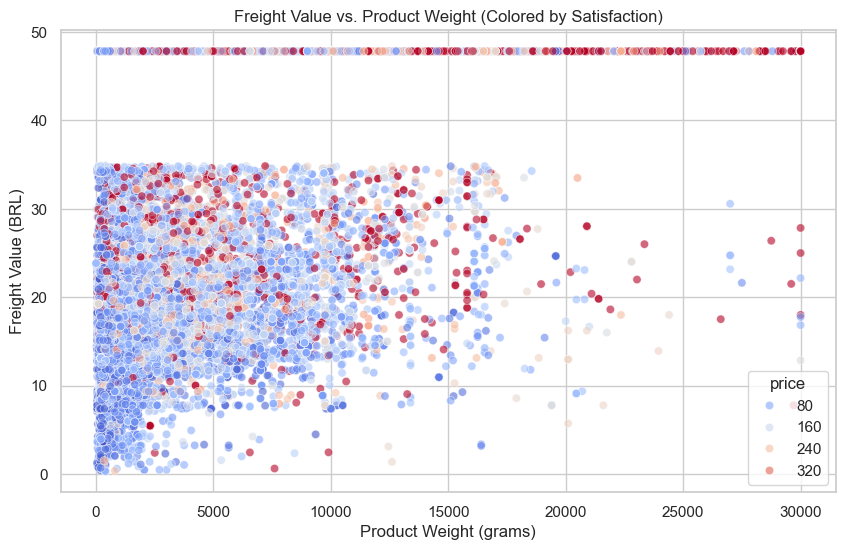

In [470]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='product_weight_g', y='freight_value', hue='price', palette='coolwarm', data=df, alpha=0.6)
plt.title('Freight Value vs. Product Weight (Colored by Satisfaction)')
plt.xlabel('Product Weight (grams)')
plt.ylabel('Freight Value (BRL)')
plt.show()

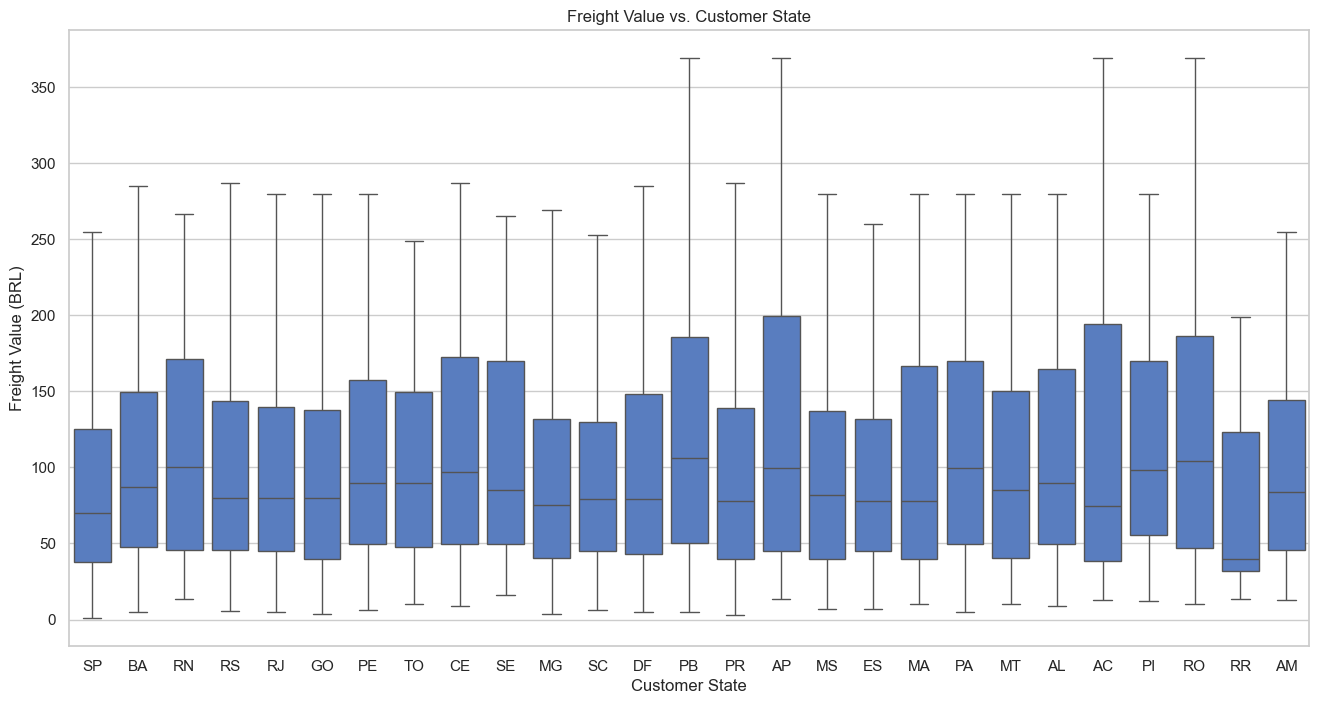

In [471]:
plt.figure(figsize=(16, 8))
sns.boxplot(x='customer_state', y='price', data=df, showfliers=False)
plt.title('Freight Value vs. Customer State')
plt.xlabel('Customer State')
plt.ylabel('Freight Value (BRL)')
plt.show()

# Visualization 4: Geospatial Supply Chain Analysis
- Business Insight: How does geography impact freight costs and delivery speeds?

/tmp/ipykernel_19190/1004891533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_freight.index, y=state_freight.values, palette='rocket')


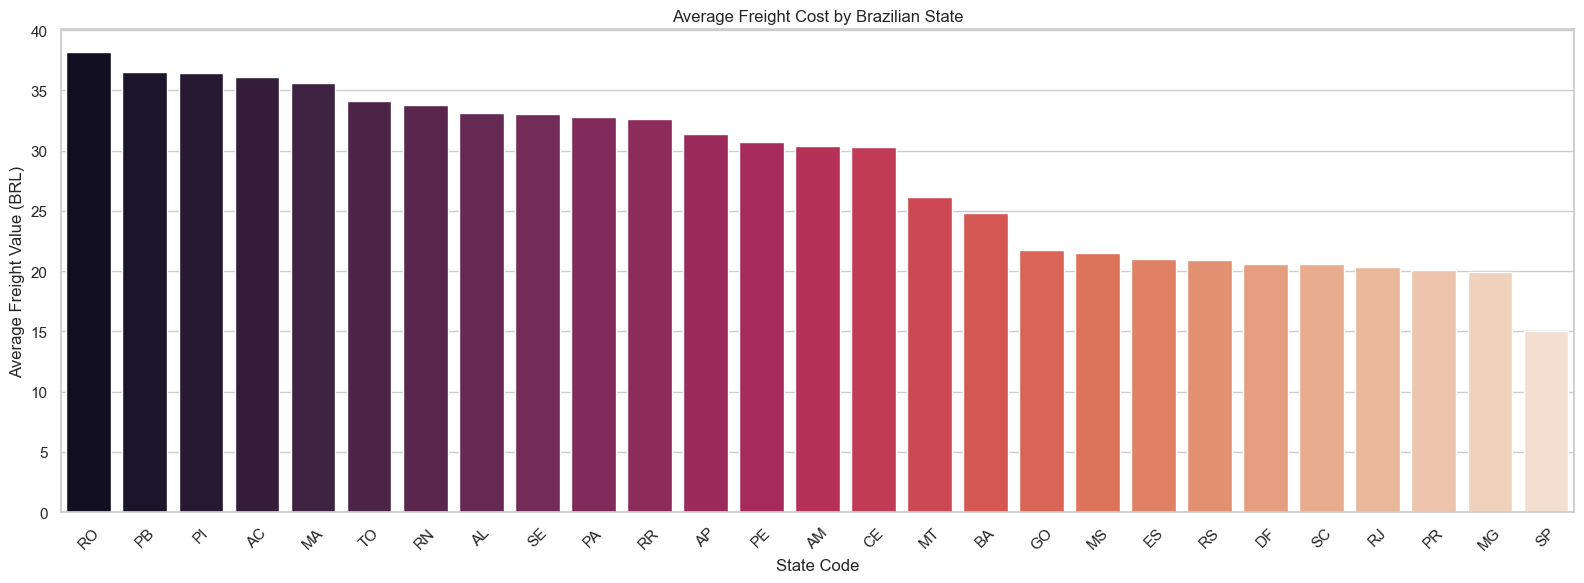

In [472]:
plt.figure(figsize=(16, 6))
state_freight = df.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False)
sns.barplot(x=state_freight.index, y=state_freight.values, palette='rocket')
plt.title('Average Freight Cost by Brazilian State')
plt.xlabel('State Code')
plt.ylabel('Average Freight Value (BRL)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Visualization 5: Hourly Transaction Patterns

/tmp/ipykernel_19190/3721603258.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_hour', data=df, palette='viridis')


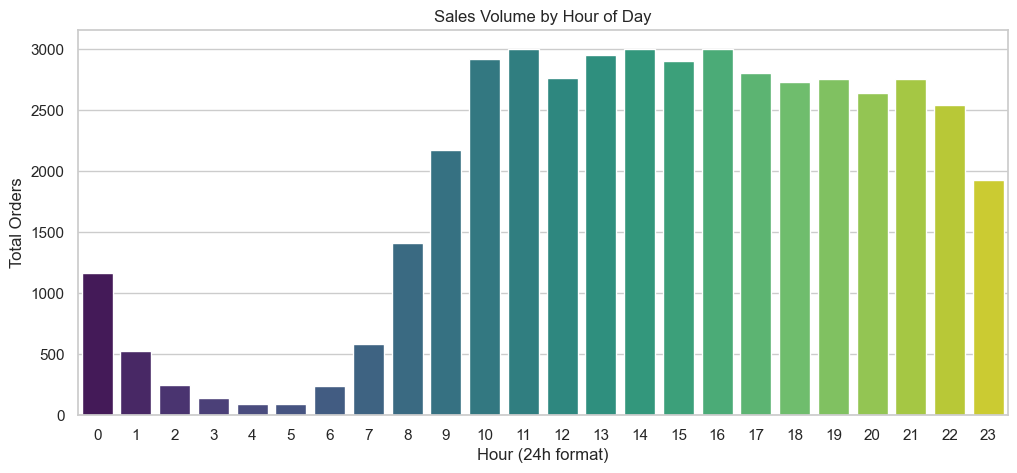

In [473]:
df['order_hour'] = df['order_purchase_timestamp'].dt.hour

plt.figure(figsize=(12, 5))
sns.countplot(x='order_hour', data=df, palette='viridis')
plt.title('Sales Volume by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Total Orders')
plt.show()